In [3]:
!pip install numpy matplotlib


[notice] A new release of pip is available: 24.3.1 -> 25.3
[notice] To update, run: pip install --upgrade pip


In [1]:
import collections
import glob
import csv
import math

import numpy as np
import matplotlib.pyplot as plt

from matplotlib.colors import TwoSlopeNorm

In [2]:
def load_group(group):
    points = collections.defaultdict(lambda: {})

    for filename in glob.glob("target/criterion/*/*/*/new/raw.csv"):
        with open(filename) as f:
            for record in csv.DictReader(f):
                if record["group"] == group:
                    function = record["function"]
                    size_x, prefix_x = record["value"].split("-")
                    _, size = size_x.split("_")
                    _, prefix = prefix_x.split("_")
                    
                    size = int(size)
                    prefix = int(prefix)
                    measured = float(record["sample_measured_value"]) / int(record["iteration_count"])
                    assert record["unit"] == "ns"

                    points[(size, prefix)][function] = measured

    return points

In [3]:
def speedup(group):
    for (size, prefix), m in load_group(group).items():
        if "vendored_std" in m and "partial_sort_1_0_0" in m:
            yield (size, prefix, m["vendored_std"] / m["partial_sort_1_0_0"])

In [81]:
def plot(scenario):
    fig, axes = plt.subplots(1, 3, sharey=True, figsize=(16, 4))

    for column, (data_type, ax) in enumerate(zip(["u64", "string", "kibibyte"], axes)):
        data = list(speedup(f"{data_type}_{scenario}"))
        sizes = np.array([d[0] for d in data])
        prefixes = np.array([d[1] for d in data])
        speedups = np.array([d[2] for d in data])
        
        sizes_vals = np.unique(sizes)
        prefixes_vals = np.unique(prefixes)
    
        Z = np.full((len(prefixes_vals), len(sizes_vals)), np.nan)
    
        for n, kf, s in data:
            i = np.where(prefixes_vals == kf)[0][0]
            j = np.where(sizes_vals == n)[0][0]
            Z[i, j] = s
    
        Z_log = np.log2(Z)
    
        mappable = ax.pcolormesh(
            sizes_vals,
            prefixes_vals,
            Z_log,
            cmap="RdYlGn_r",
            norm=TwoSlopeNorm(vmin=-3, vcenter=0, vmax=3)
        )

        ax.set_title(f"{scenario} {data_type}")
        ax.set_xscale("log")
        ax.set_xlim([5, None])
        ax.set_ylim([0, 100])
        ax.set_xlabel("slice length")
        if column == 0:
            ax.set_ylabel("prefix percent")

        for exp in range(0, 7):
            ax.plot(range(1, 8000), [(2 ** exp) / x * 100 for x in range(1, 8000)], 'k--')

    cbar = fig.colorbar(mappable, ax=axes)
    cbar.set_ticks([-2, -1, 0, 1, 2])
    cbar.set_ticklabels(["0.25", "0.5", "1", "2", "4"])

    plt.show()

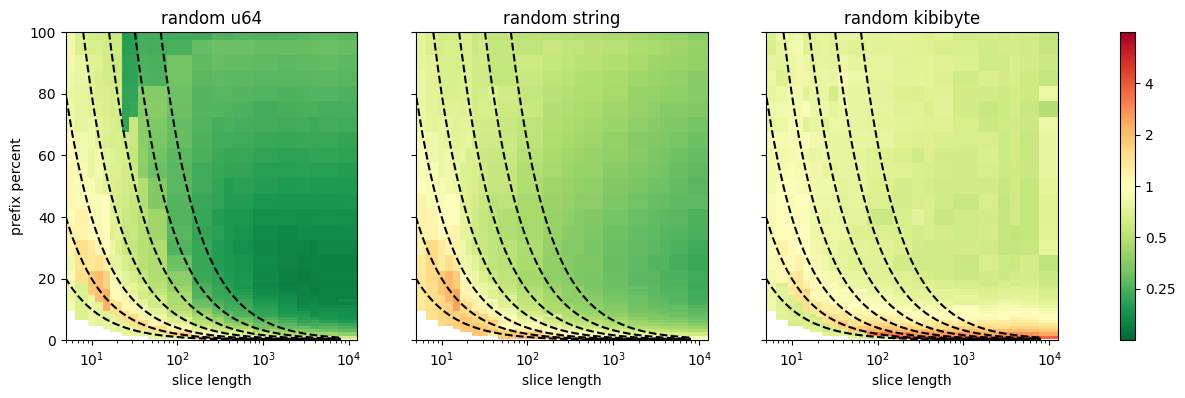

In [83]:
plot("random")

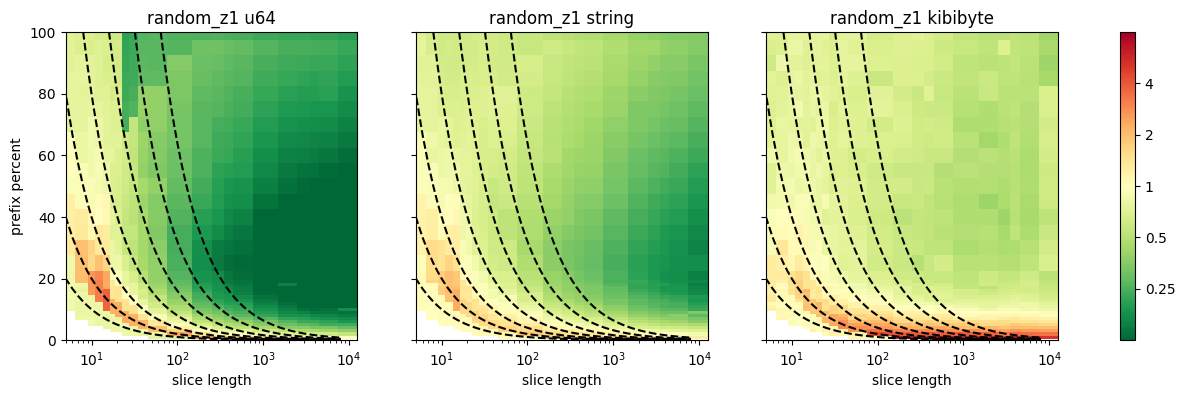

In [84]:
plot("random_z1")

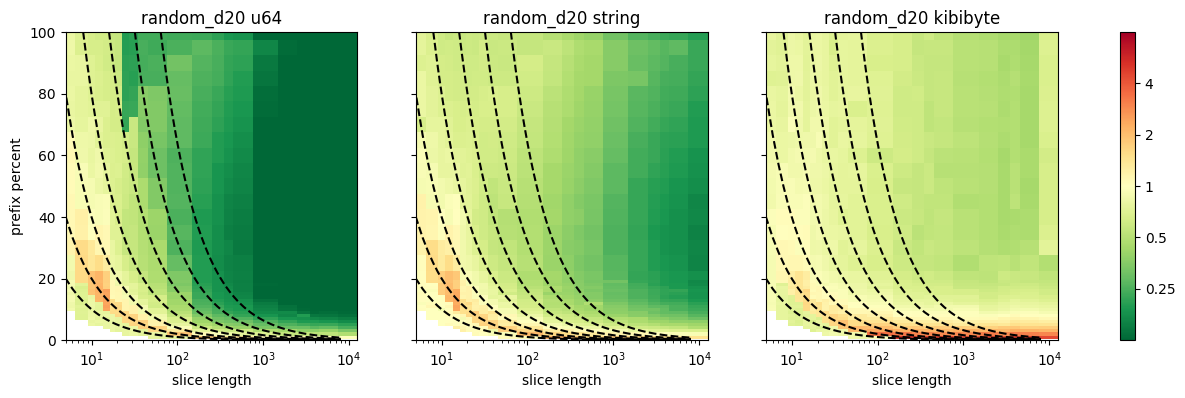

In [85]:
plot("random_d20")

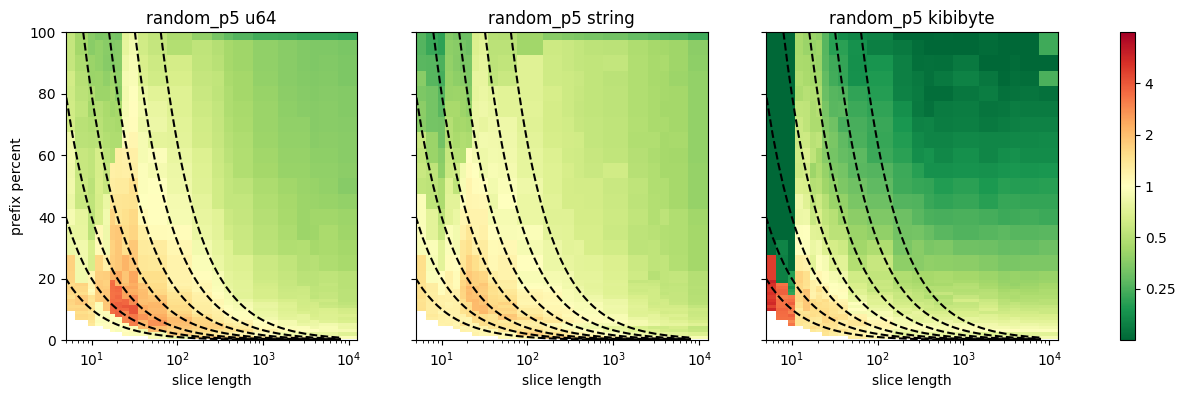

In [86]:
plot("random_p5")

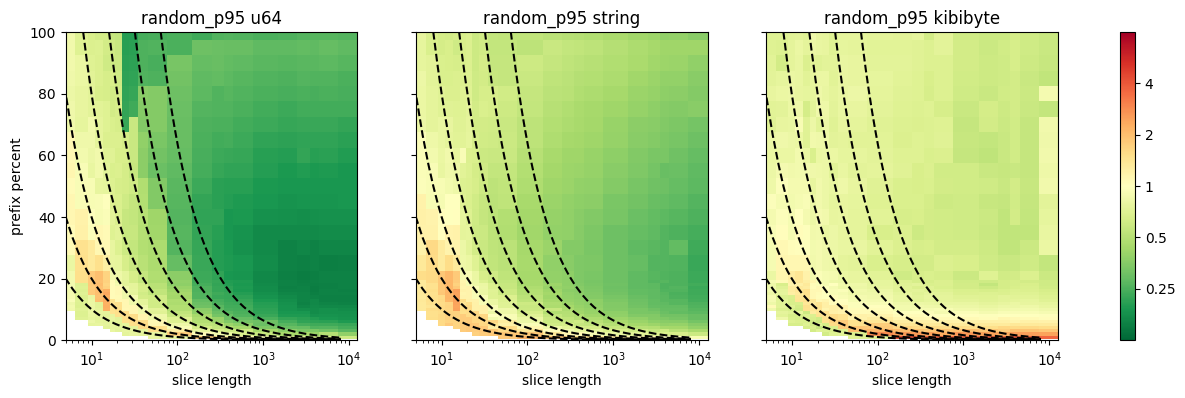

In [87]:
plot("random_p95")

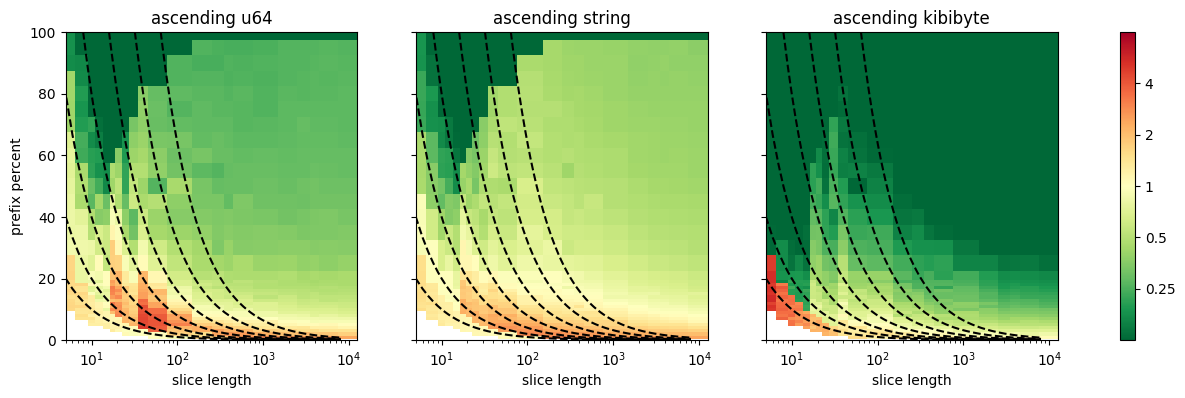

In [88]:
plot("ascending")

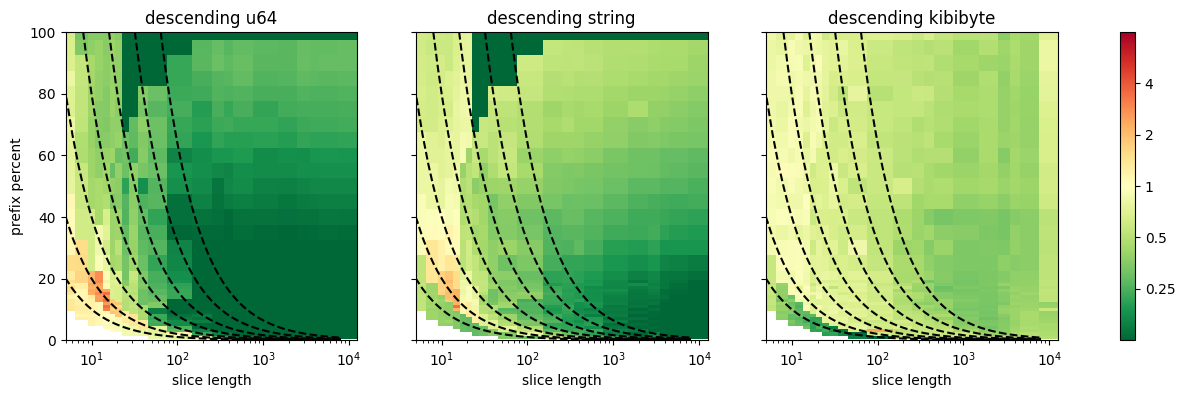

In [89]:
plot("descending")